In [2]:
#libraries used
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

In [3]:
#data file from "https://uknowledge.uky.edu/ees_data/2/#attach_additional_files"
#columns are : Longitude (degree), Latitude (degree), Br, Btheta, Bphi and Total Field components
file_path = '/Users/hectar/Downloads/New Magnetic Field Models of the Moon.dat'

with open(file_path, 'r') as file:
    content = file.read()
    print(content)


for line in open(file_path):
    columns = line.split(" ")

295.000 0.000 5.292 3.03 -0.392 6.117
295.000 0.100 8.56 0.308 -1.02 8.64
295.000 0.200 6.302 -3.787 -0.664 7.408
295.000 0.300 2.05 -4.279 0.022 4.781
295.000 0.400 -0.794 -3.582 0.57 3.761
295.000 0.500 -3.382 -2.671 1.316 4.554
295.000 0.600 -5.105 -0.065 2.076 5.554
295.000 0.700 -4.16 2.445 2.522 5.478
295.000 0.800 -2.832 4.535 2.912 6.108
295.000 0.900 -0.535 7.352 2.584 7.817
295.000 1.000 3.491 10.466 1.9 11.2
295.000 1.100 10.944 14.396 1.393 18.142
295.000 1.200 25.417 15.655 0.74 29.863
295.000 1.300 37.622 4.457 -0.131 37.91
295.000 1.400 33.421 -4.989 -1.136 33.932
295.000 1.500 30.926 -10.091 -2.635 32.827
295.000 1.600 21.271 -18.045 -1.636 28.036
295.000 1.700 8.489 -17.535 0.466 19.506
295.000 1.800 1.256 -14.181 1.527 14.32
295.000 1.900 -2.944 -12.508 1.839 12.981
295.000 2.000 -7.617 -12.816 1.51 14.988
295.000 2.100 -16.167 -13.83 0.635 21.288
295.000 2.200 -27.603 -7.772 0.213 28.677
295.000 2.300 -24.214 3.906 0.498 24.532
295.000 2.400 -14.103 4.884 1.583 15.01

In [5]:
def x_coordinates():
    values = []
    for line in open(file_path):
        columns = line.split(" ")
        values.append((float(columns[0])) )
    return values


def y_coordinates():
    values = []
    for line in open(file_path):
        columns = line.split(" ")
        values.append((float(columns[1])))
    return values

x_values = x_coordinates()
y_values = y_coordinates()

x_differences = np.diff(x_values)
print("Smallest difference between consecutive x-values:", x_differences.min())
print("Largest difference between consecutive x-values:", x_differences.max())

y_differences = np.diff(y_values)
print("Smallest difference between consecutive y-values:", y_differences.min())
print("Largest difference between consecutive y-values:", y_differences.max())

Smallest difference between consecutive x-values: 0.0
Largest difference between consecutive x-values: 0.10000000000002274
Smallest difference between consecutive y-values: -15.0
Largest difference between consecutive y-values: 0.10000000000000142


In [6]:
#magnetic field
def magnetic_field():
    values = []
    for line in open(file_path):
        columns = line.split(" ")
        values.append((float(columns[2])))
    return values

field = magnetic_field()
position_fields = []

for position_field in zip(x_values, y_values, field):
    position_fields.append(position_field)

#each position with related magnetic field

position = np.array([0, 0, 0])
position_field_array= np.array(position_fields)

print(position_field_array)


[[ 2.950e+02  0.000e+00  5.292e+00]
 [ 2.950e+02  1.000e-01  8.560e+00]
 [ 2.950e+02  2.000e-01  6.302e+00]
 ...
 [ 3.100e+02  1.480e+01 -3.300e-01]
 [ 3.100e+02  1.490e+01  3.870e-01]
 [ 3.100e+02  1.500e+01  4.180e-01]]


Magnetic Field Grid:
(151, 151)


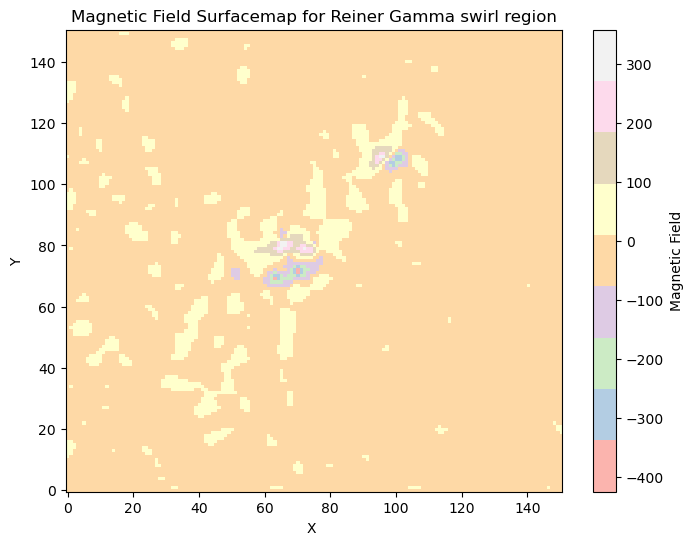

In [7]:
x_unique = np.unique(x_values)
y_unique = np.unique(y_values)

# Initialize the grid (size based on unique x and y values)
B_grid = np.zeros((len(y_unique), len(x_unique)))


# Fill the grid with the corresponding magnetic field values
for i in range(len(x_values)):
    # Get the index for the x and y values in the unique list
    x_idx = np.where(x_unique == x_values[i])[0][0]  
    y_idx = np.where(y_unique == y_values[i])[0][0] 
    
    # place the field value in the grid at the position corresponding to (x, y)
    B_grid[y_idx, x_idx] = field[i]

# Print the grid after filling it
print("Magnetic Field Grid:")
print((B_grid.shape))

plt.figure(figsize=(8, 6))

# Create the heatmap using imshow()
# The extent argument helps us map the grid's pixel locations to the x and y values
plt.imshow(B_grid, cmap='Pastel1', origin='lower', aspect='auto')

# Add colorbar to show the magnetic field value scale
plt.colorbar(label='Magnetic Field')

# Label the axes
plt.xlabel('X ')
plt.ylabel('Y')

# Title
plt.title('Magnetic Field Surfacemap for Reiner Gamma swirl region')

# Show the plot
plt.show()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/rh/9fnxh6s94fj1g_3ls0fwffbc0000gn/T/ipykernel_68691/735998969.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep="\s+", header=None)


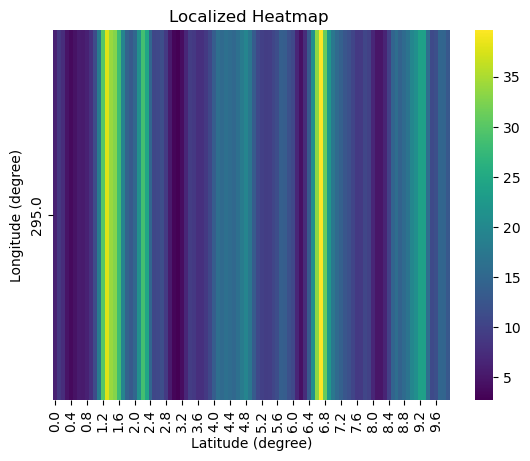

In [8]:
df = pd.read_csv(file_path, sep="\s+", header=None)

# Assuming the columns are not named, you can manually assign column names
df.columns = ['Longitude (degree)', 'Latitude (degree)', 'Field Value 1', 'Field Value 2', 'Field Value 3', 'Total Field components']

df_localized = df.head(100)

# Now pivot the data into the desired format for heatmap using the first 200 rows
pivot_data = df_localized.pivot(index='Longitude (degree)', columns='Latitude (degree)', values='Total Field components')

# Plot the heatmap
sns.heatmap(pivot_data, cmap="viridis", annot=False)  # You can customize the colormap (e.g., viridis, coolwarm)
plt.title('Localized Heatmap ')
plt.show()

In [9]:
# calculation of distance
MOON_RADIUS = 1738.1/1.6093

def distance(lat1, lat2, lon1, lon2):
	
	# The math module contains a function named
	# radians which converts from degrees to radians.
	lon1 = radians(lon1)
	lon2 = radians(lon2)
	lat1 = radians(lat1)
	lat2 = radians(lat2)
	
	# Haversine formula 
	dlon = lon2 - lon1 
	dlat = lat2 - lat1
	a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2

	c = 2 * asin(sqrt(a)) 
	
	# calculate the result
	return round((c * MOON_RADIUS), 3)
	
	
# for two points in the dataset
lat1 = x_values[1]
lat2 = x_values[1]
lon1 = y_values[1]
lon2 = y_values[2]
print(f"The distance between two points on the same latitude is {distance(lat1, lat2, lon1, lon2) * 1000} meters")


The distance between two points on the same latitude is 797.0 meters


In [71]:
#constants
INITIAL_X_VELOCITY = 1
INITIAL_Y_VELOCITY = 2  
INITIAL_Z_VELOCITY = 1
INITIAL_HEIGHT = 2

dt = 0.01  # Time step (seconds)
TIME = 0.1
STEPS = 10
ELECTRIC_FIELD = 20

#for hydrogen
q = 1.6e-19  # Charge of particle (Coulombs)
m = 9.11e-1  # Mass of particle (kg)

In [72]:
#electric field calculation
def electric_field(height):
    transition_height = 15
    mean = ELECTRIC_FIELD

    if height <= transition_height:
        strength = mean * height / transition_height

    else:
        strength = mean + (height - transition_height)  

    return np.array([0, 0, strength])

In [88]:
def distance_3d(lat1, lat2, lon1, lon2, z1, z2):
    """
    Calculate the 3D distance between two points in space (lat, lon, and height).
    """
    # Convert latitudes, longitudes, and heights to radians
    lon1, lon2, lat1, lat2 = map(radians, [lon1, lon2, lat1, lat2])
    
    # Haversine formula for the spherical distance (latitude and longitude only)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    
    # Clamp 'a' to the valid range for asin (to avoid math domain errors)
    a = np.clip(a, 0, 1)  # Ensure 'a' is within [0, 1] range for asin
    
    c = 2 * asin(sqrt(a))
    spherical_distance = c * MOON_RADIUS  # Result in meters
    
    # Calculate the difference in the z-coordinate (height)
    vertical_distance = abs(z1 - z2)
    
    # Combine spherical and vertical distances (Pythagorean theorem for 3D)
    total_distance = sqrt(spherical_distance**2 + vertical_distance**2)
    
    return total_distance


def derivatives(state, q, m, position_field_array, electric_field):
    """Calculate the derivatives of the state vector considering the full 3D distance."""
    position = state[0:3]  # Position: [x, y, z]
    velocity = state[3:6]  # Velocity: [vx, vy, vz]
    height = position[2]  # z-coordinate as height

    # Calculate the electric field using the provided electric field function
    E = electric_field(height)
    
    # Ensure position_field_array is a numpy array for indexing
    position_field_array = np.array(position_field_array)
    
    # Find the closest magnetic field point using 3D distance
    distance_3d_values = np.array([
        distance_3d(position[1], y, position[0], x, position[2], z)
        for x, y, z in position_field_array[:, 0:3]
    ])
    
    closest_index = np.argmin(distance_3d_values)  # Find the closest point index
    B = position_field_array[closest_index, 0:3]  # Extract the 3D magnetic field vector
    
    # Calculate the Lorentz force and thus the acceleration
    # Magnetic force: F = q * (v x B)
    magnetic_force = np.cross(velocity, B)
    electric_force = q * E
    
    # Total force (Lorentz force)
    total_force = electric_force + magnetic_force
    
    # Acceleration = Force / mass
    acceleration = total_force / m
    
    # Derivatives: position velocity and velocity acceleration
    drdt = velocity
    dvdt = acceleration  # The change in velocity over time
    
    return np.concatenate((drdt, dvdt))  # Return both position and velocity changes


def runge_kutta(state, q, m, position_field_array, electric_field_fun):
    """Performs a single Runge-Kutta step."""
    
    # Calculate the derivatives for k1
    k1 = dt * derivatives(state, q, m, position_field_array, electric_field_fun)
    
    # Step 2: Calculate the derivatives for k2
    k2 = dt * derivatives(state + 0.5 * k1, q, m, position_field_array, electric_field_fun)
    
    # Step 3: Calculate the derivatives for k3
    k3 = dt * derivatives(state + 0.5 * k2, q, m, position_field_array, electric_field_fun)
    
    # Step 4: Calculate the derivatives for k4
    k4 = dt * derivatives(state + k3, q, m, position_field_array, electric_field_fun)
    
    # Update the state based on the Runge-Kutta formula
    new_state = state + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    
    return new_state


state = np.array([0, 0, INITIAL_HEIGHT, INITIAL_X_VELOCITY, INITIAL_Y_VELOCITY, INITIAL_Z_VELOCITY])

In [89]:
# Array to store trajectory results, including time
trajectories = []

# Time step tracking
time = 0

# Run the simulation for the specified number of time steps
for step in range(STEPS):
    # Runge-Kutta step to update the state
    state = runge_kutta(state, q, m, position_fields, electric_field)
    
    # Extract the position and velocity from the state vector
    position = state[0:3]  # [x, y, z]
    velocity = state[3:6]  # [vx, vy, vz]
    
    # Append the current position and velocity to the trajectory list
    trajectories.append(np.concatenate((position, velocity)))

# Convert the trajectory list to a numpy array for easier handling
trajectories = np.array(trajectories)
print(trajectories[:10])

# Extract the x, y, z positions and velocities for plotting or further analysis
x_trajectory = trajectories[:, 0]
y_trajectory = trajectories[:, 1]
z_trajectory = trajectories[:, 2]
vx_trajectory = trajectories[:, 3]
vy_trajectory = trajectories[:, 4]
vz_trajectory = trajectories[:, 5]

[[ 1.00685278e-02 -1.80043421e-02  1.98957343e+00  9.79446196e-01
  -1.55950301e+00  7.12661477e+00]
 [ 2.04352267e-02  7.37876335e-04  1.92429786e+00  1.01013789e+00
  -2.37859039e+01  7.49738298e-01]
 [ 3.05373571e-02  2.22373705e-01  1.93157124e+00  1.63003737e+00
  -2.13247518e+01 -7.46677274e+01]
 [ 4.12780342e-02  3.76191124e-01  2.63875096e+00  1.63689644e+00
   2.19302777e+02 -1.27007480e+02]
 [ 8.70168558e-02 -1.73863613e+00  3.68970782e+00  6.15765737e+00
   5.76872007e+02  5.92693844e+02]
 [ 6.66192282e-01 -6.74842023e+00 -2.15582684e+00  9.60535877e+01
  -1.41265138e+03  2.29915159e+03]
 [ 1.73406688e+00  7.76457024e+00 -2.26693723e+01  6.65873707e+02
  -8.39296804e+03 -2.63175167e+03]
 [ 9.70958826e+00  8.43717219e+01  6.44609743e+00  1.70248577e+03
   2.66346024e+03 -2.70963723e+04]
 [ 3.99753443e+01  2.22022317e+01  2.16895223e+02  3.87799532e+03
   7.35533276e+04 -1.07116666e+04]
 [ 1.16886754e+02 -6.64317819e+02  2.72091932e+02  2.35004163e+04
   9.14973599e+04  2.2281

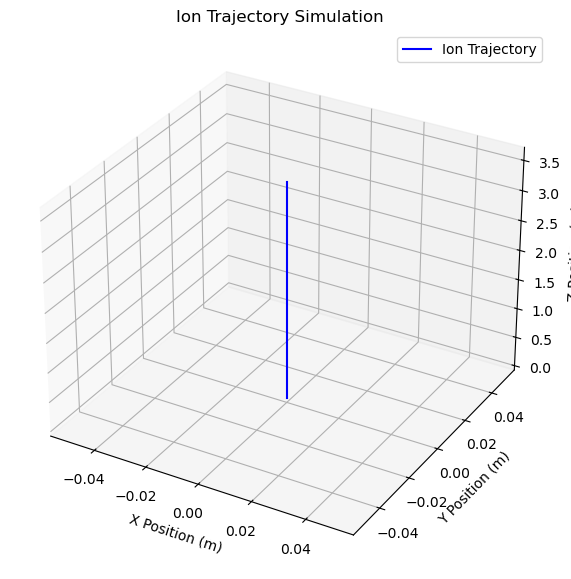

In [28]:
from mpl_toolkits.mplot3d import Axes3D

# Plot the ion trajectory
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D trajectory
ax.plot(x_trajectory, y_trajectory, z_trajectory, label="Ion Trajectory", color='b')

# Labels and title
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_zlabel('Z Position (m)')
ax.set_title('Ion Trajectory Simulation')

plt.legend()
plt.show()
